In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # use GPU 1


In [ ]:
# OLD (broken):
# from dingo.core.models import PosteriorModel
# main_pm = PosteriorModel(device="cuda", model_filename="...", load_training_info=False)

# NEW:
from dingo.core.posterior_models.build_model import build_model_from_kwargs

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/ET_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)




WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.


In [3]:
import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)


injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
asd_dataset = ASDDataset(file_name=asd_fname)
injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

intrinsic_parameters = {
    "chirp_mass": 80.,
    "mass_ratio": 0.8,
    "a_1": .3,
    "a_2": .5,
    "tilt_1": 0.,
    "tilt_2": 0.,
    "phi_jl": 0.,
    "phi_12": 0.
}

extrinsic_parameters = {
    'phase': 0.,
    'theta_jn': 2.3,
    'geocent_time': 0.,
    'luminosity_distance': 1000.,
    'ra': 0.,
    'dec': 0.,
    'psi': 0.,
}

theta = {**intrinsic_parameters, **extrinsic_parameters}
strain_data = injection_generator.injection(theta)
# Returns dict with keys: 'waveform', 'parameters', 'extrinsic_parameters', 'asd'

/home/tpausch/ET-Dingo/dingo/gw/__init__.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.


Running sampler to generate 50000 samples.
Done. This took 5.3 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



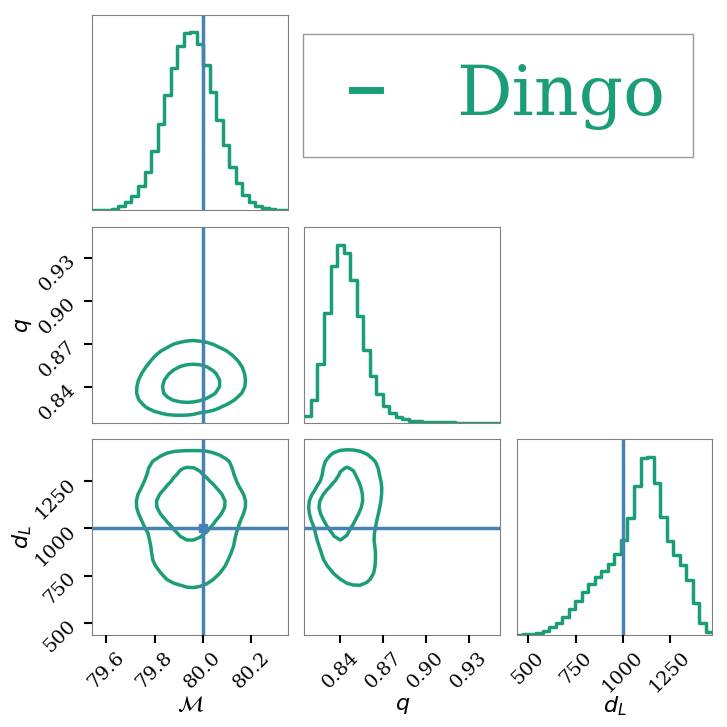

In [4]:
from dingo.gw.inference.gw_samplers import  GWSampler
sampler =GWSampler(model=main_pm)
sampler.context = strain_data
sampler.run_sampler(num_samples=50_000, batch_size=10_000)
result = sampler.to_result()
#result.plot_corner(parameters=["chirp_mass", "mass_ratio", "luminosity_distance"])
result.plot_corner(
    parameters=["chirp_mass", "mass_ratio", "luminosity_distance"],
    truths=[80, 0.8, 1000.0]
)

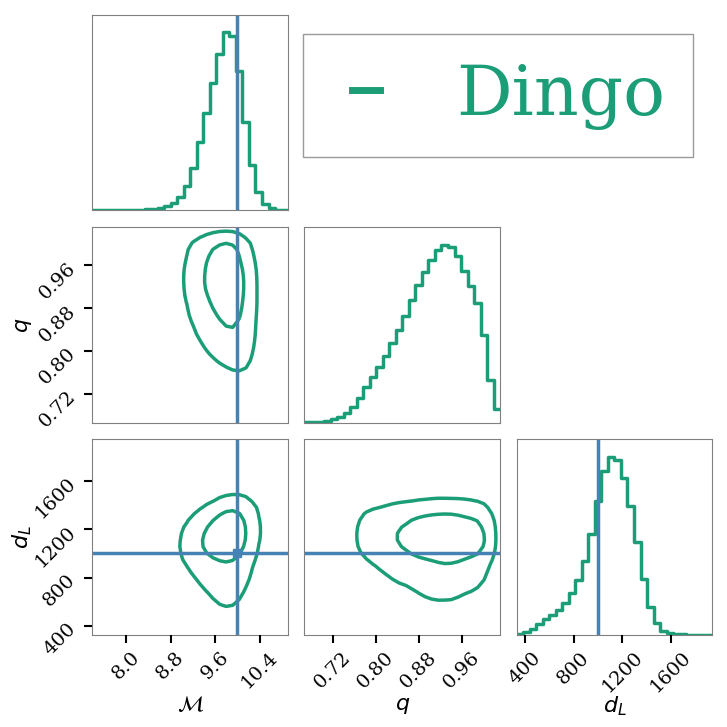

In [25]:
result.plot_corner(
    parameters=["chirp_mass", "mass_ratio", "luminosity_distance"],
    truths=[10, 0.5, 1000.0]
)

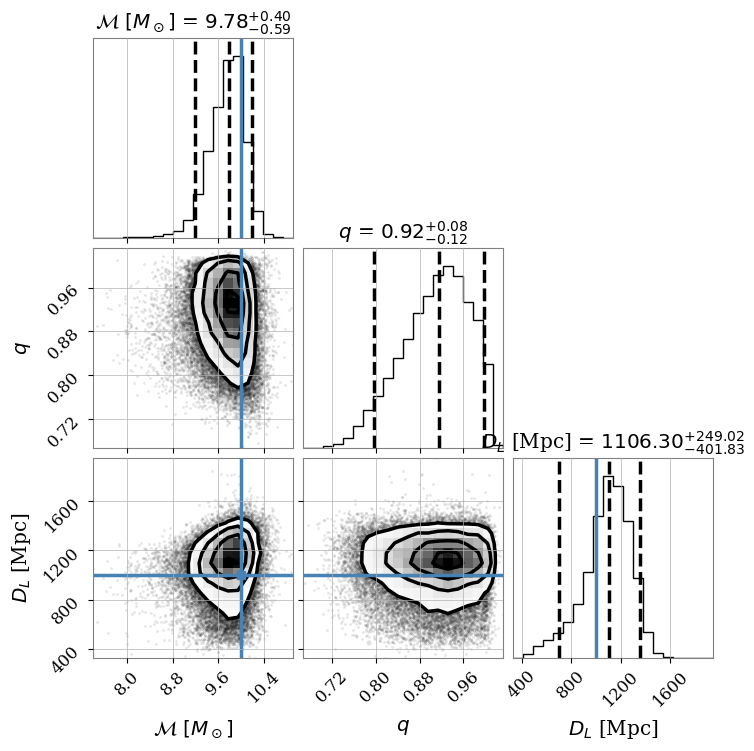

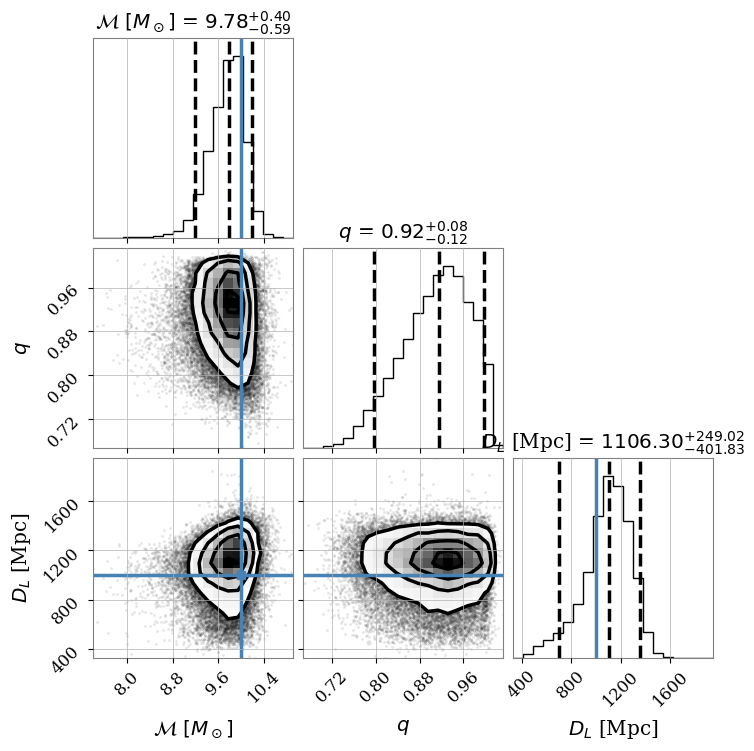

In [24]:
import corner

params = ["chirp_mass", "mass_ratio", "luminosity_distance"]
labels = [r"$\mathcal{M}$ $[M_\odot]$", r"$q$", r"$D_L$ [Mpc]"]
injection_values = [10, 0.5, 1000.0]

corner.corner(
    result.samples[params].to_numpy(),
    labels=labels,
    truths=injection_values,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
)


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Using phase marginalization with (2,2) mode approximation.


Calculating 21194 likelihoods.
Done. This took 17.53 seconds.
Sample efficiency: 0.000
log Bayes factor: 770710.34


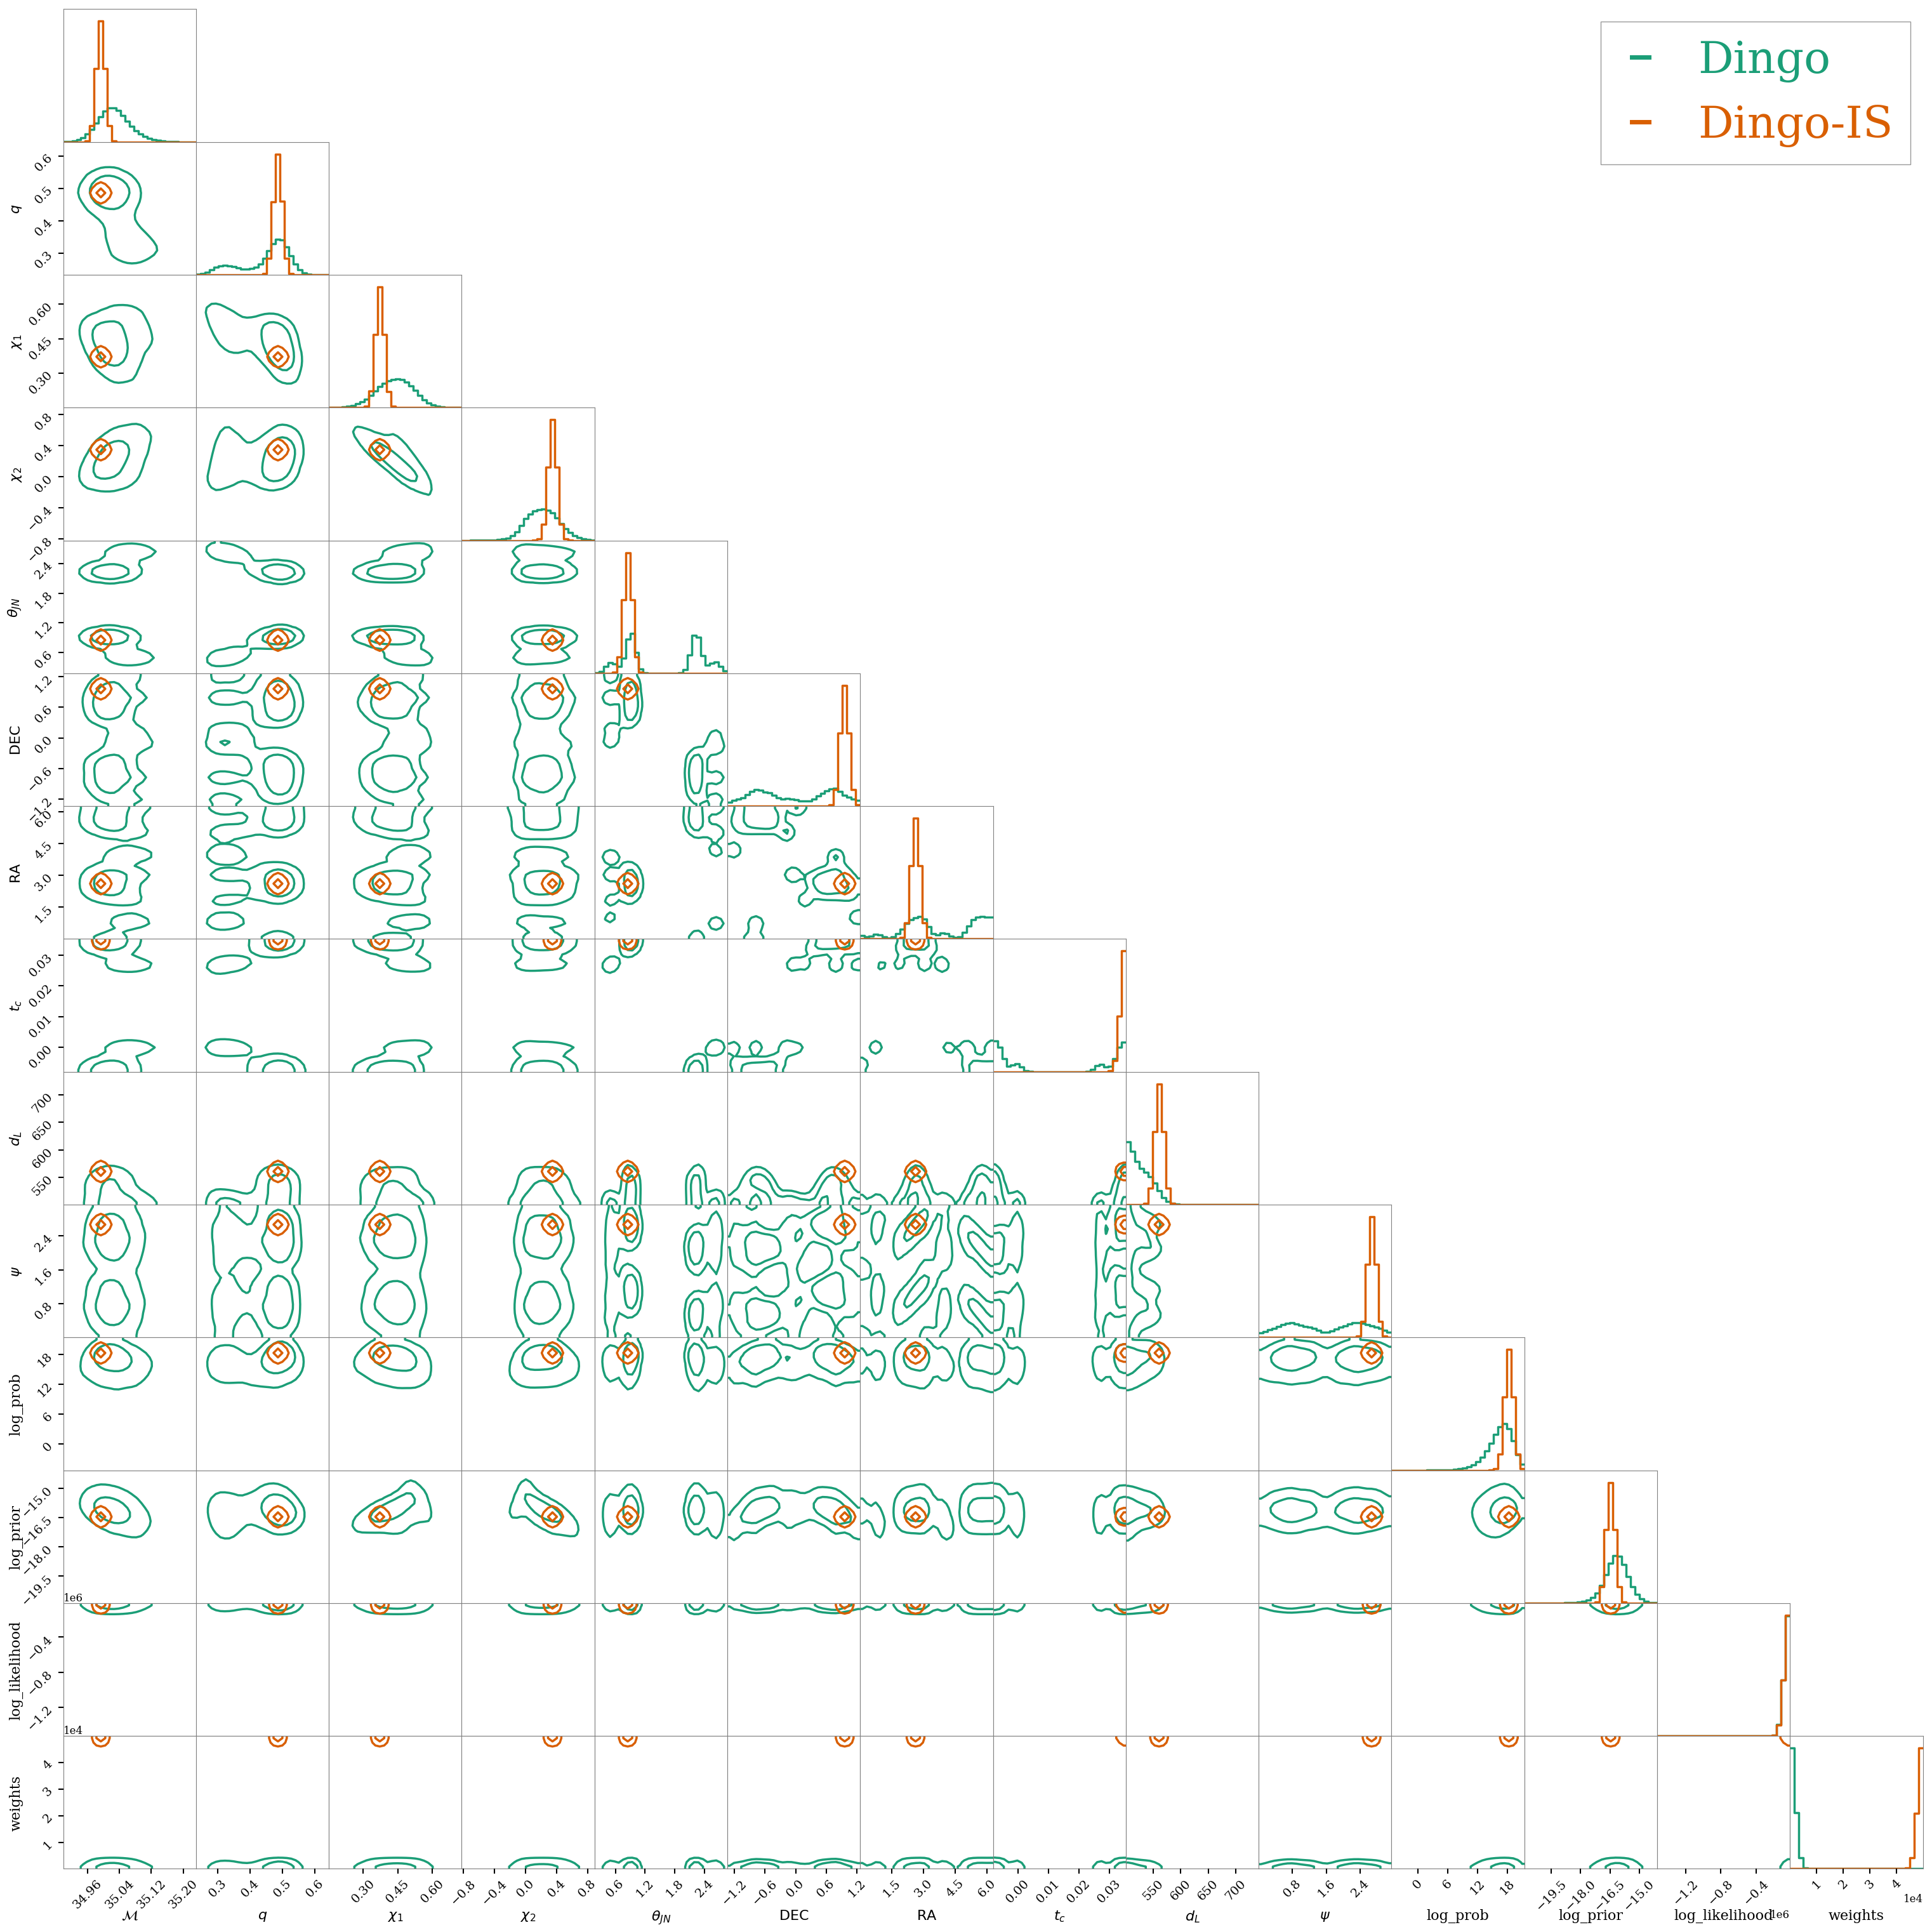

In [5]:
from dingo.gw.inference.gw_samplers import GWSampler

result = sampler.to_result()



result.importance_sample(
    num_processes=32,
    phase_marginalization_kwargs={},
)

# These are now available after importance sampling:
print(f"Sample efficiency: {result.sample_efficiency:.3f}")  # ideally > ~10%
print(f"log Bayes factor: {result.log_bayes_factor:.2f}")

result.plot_corner()

In [6]:
import numpy as np

# Look at the raw log weights before normalization
print(result.samples[["log_prob", "log_likelihood", "log_prior"]].describe())

# The IS log weights are: log_likelihood + log_prior - log_prob
log_weights = (
    result.samples["log_likelihood"]
    + result.samples["log_prior"]
    - result.samples["log_prob"]
)
print("\nlog weights stats:")
print(log_weights.describe())
print(f"\nMax log weight: {log_weights.max():.1f}")
print(f"Mean log weight: {log_weights.mean():.1f}")
print(f"Std log weight: {log_weights.std():.1f}")

           log_prob  log_likelihood     log_prior
count  50000.000000    2.119400e+04  5.000000e+04
mean      16.271561   -2.847107e+04          -inf
std        2.409266    6.281039e+04           NaN
min       -7.025261   -1.526551e+06          -inf
25%       14.955343   -3.155278e+04           NaN
50%       16.658976   -2.257196e+04           NaN
75%       18.008424   -1.739512e+04 -1.626463e+01
max       21.410698   -1.253366e+04 -1.408365e+01

log weights stats:
count    2.119400e+04
mean    -2.850362e+04
std      6.280993e+04
min     -1.526576e+06
25%     -3.158203e+04
50%     -2.260369e+04
75%     -1.742698e+04
max     -1.256817e+04
dtype: float64

Max log weight: -12568.2
Mean log weight: -28503.6
Std log weight: 62809.9


/home/tpausch/.conda/envs/ET-DINGO/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/tpausch/.conda/envs/ET-DINGO/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


In [8]:
print("Prior keys:  ", sorted(result.prior.keys()))
print("Sample cols: ", sorted([c for c in result.samples.columns if c != "log_prob"]))

Prior keys:   ['chi_1', 'chi_2', 'chirp_mass', 'dec', 'geocent_time', 'luminosity_distance', 'mass_1', 'mass_2', 'mass_ratio', 'psi', 'ra', 'theta_jn']
Sample cols:  ['chi_1', 'chi_2', 'chirp_mass', 'dec', 'geocent_time', 'log_likelihood', 'log_prior', 'luminosity_distance', 'mass_ratio', 'psi', 'ra', 'theta_jn', 'weights']


In [9]:
from bilby.gw.prior import BBHPriorDict

# Drop the redundant mass parameterization from the prior
for key in ["mass_1", "mass_2"]:
    if key in result.prior:
        del result.prior[key]

print("Prior keys after fix:", sorted(result.prior.keys()))
print("Sample cols:         ", sorted([c for c in result.samples.columns if c != "log_prob"]))

# Now retry importance sampling
result.importance_sample(
    num_processes=32,
    phase_marginalization_kwargs={},
)

print(f"Sample efficiency: {result.sample_efficiency:.3f}")
print(f"log Bayes factor:  {result.log_bayes_factor:.2f}")

Prior keys after fix: ['chi_1', 'chi_2', 'chirp_mass', 'dec', 'geocent_time', 'luminosity_distance', 'mass_ratio', 'psi', 'ra', 'theta_jn']
Sample cols:          ['chi_1', 'chi_2', 'chirp_mass', 'dec', 'geocent_time', 'log_likelihood', 'log_prior', 'luminosity_distance', 'mass_ratio', 'psi', 'ra', 'theta_jn', 'weights']
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Using phase marginalization with (2,2) mode approximation.
Calculating 21194 likelihoods.
Done. This took 22.73 seconds.
Sample efficiency: 0.000
log Bayes factor:  770709.20


Running sampler to generate 50000 samples.
Done. This took 5.1 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Prior keys after fix: ['chi_1', 'chi_2', 'chirp_mass', 'dec', 'geocent_time', 'luminosity_distance', 'mass_ratio', 'psi', 'ra', 'theta_jn']
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Using phase marginalization with (2,2) mode approximation.
Calculating 23189 likelihoods.
Done. This took 20.40 seconds.
Sample efficiency: 0.000
log Bayes factor:  773557.22


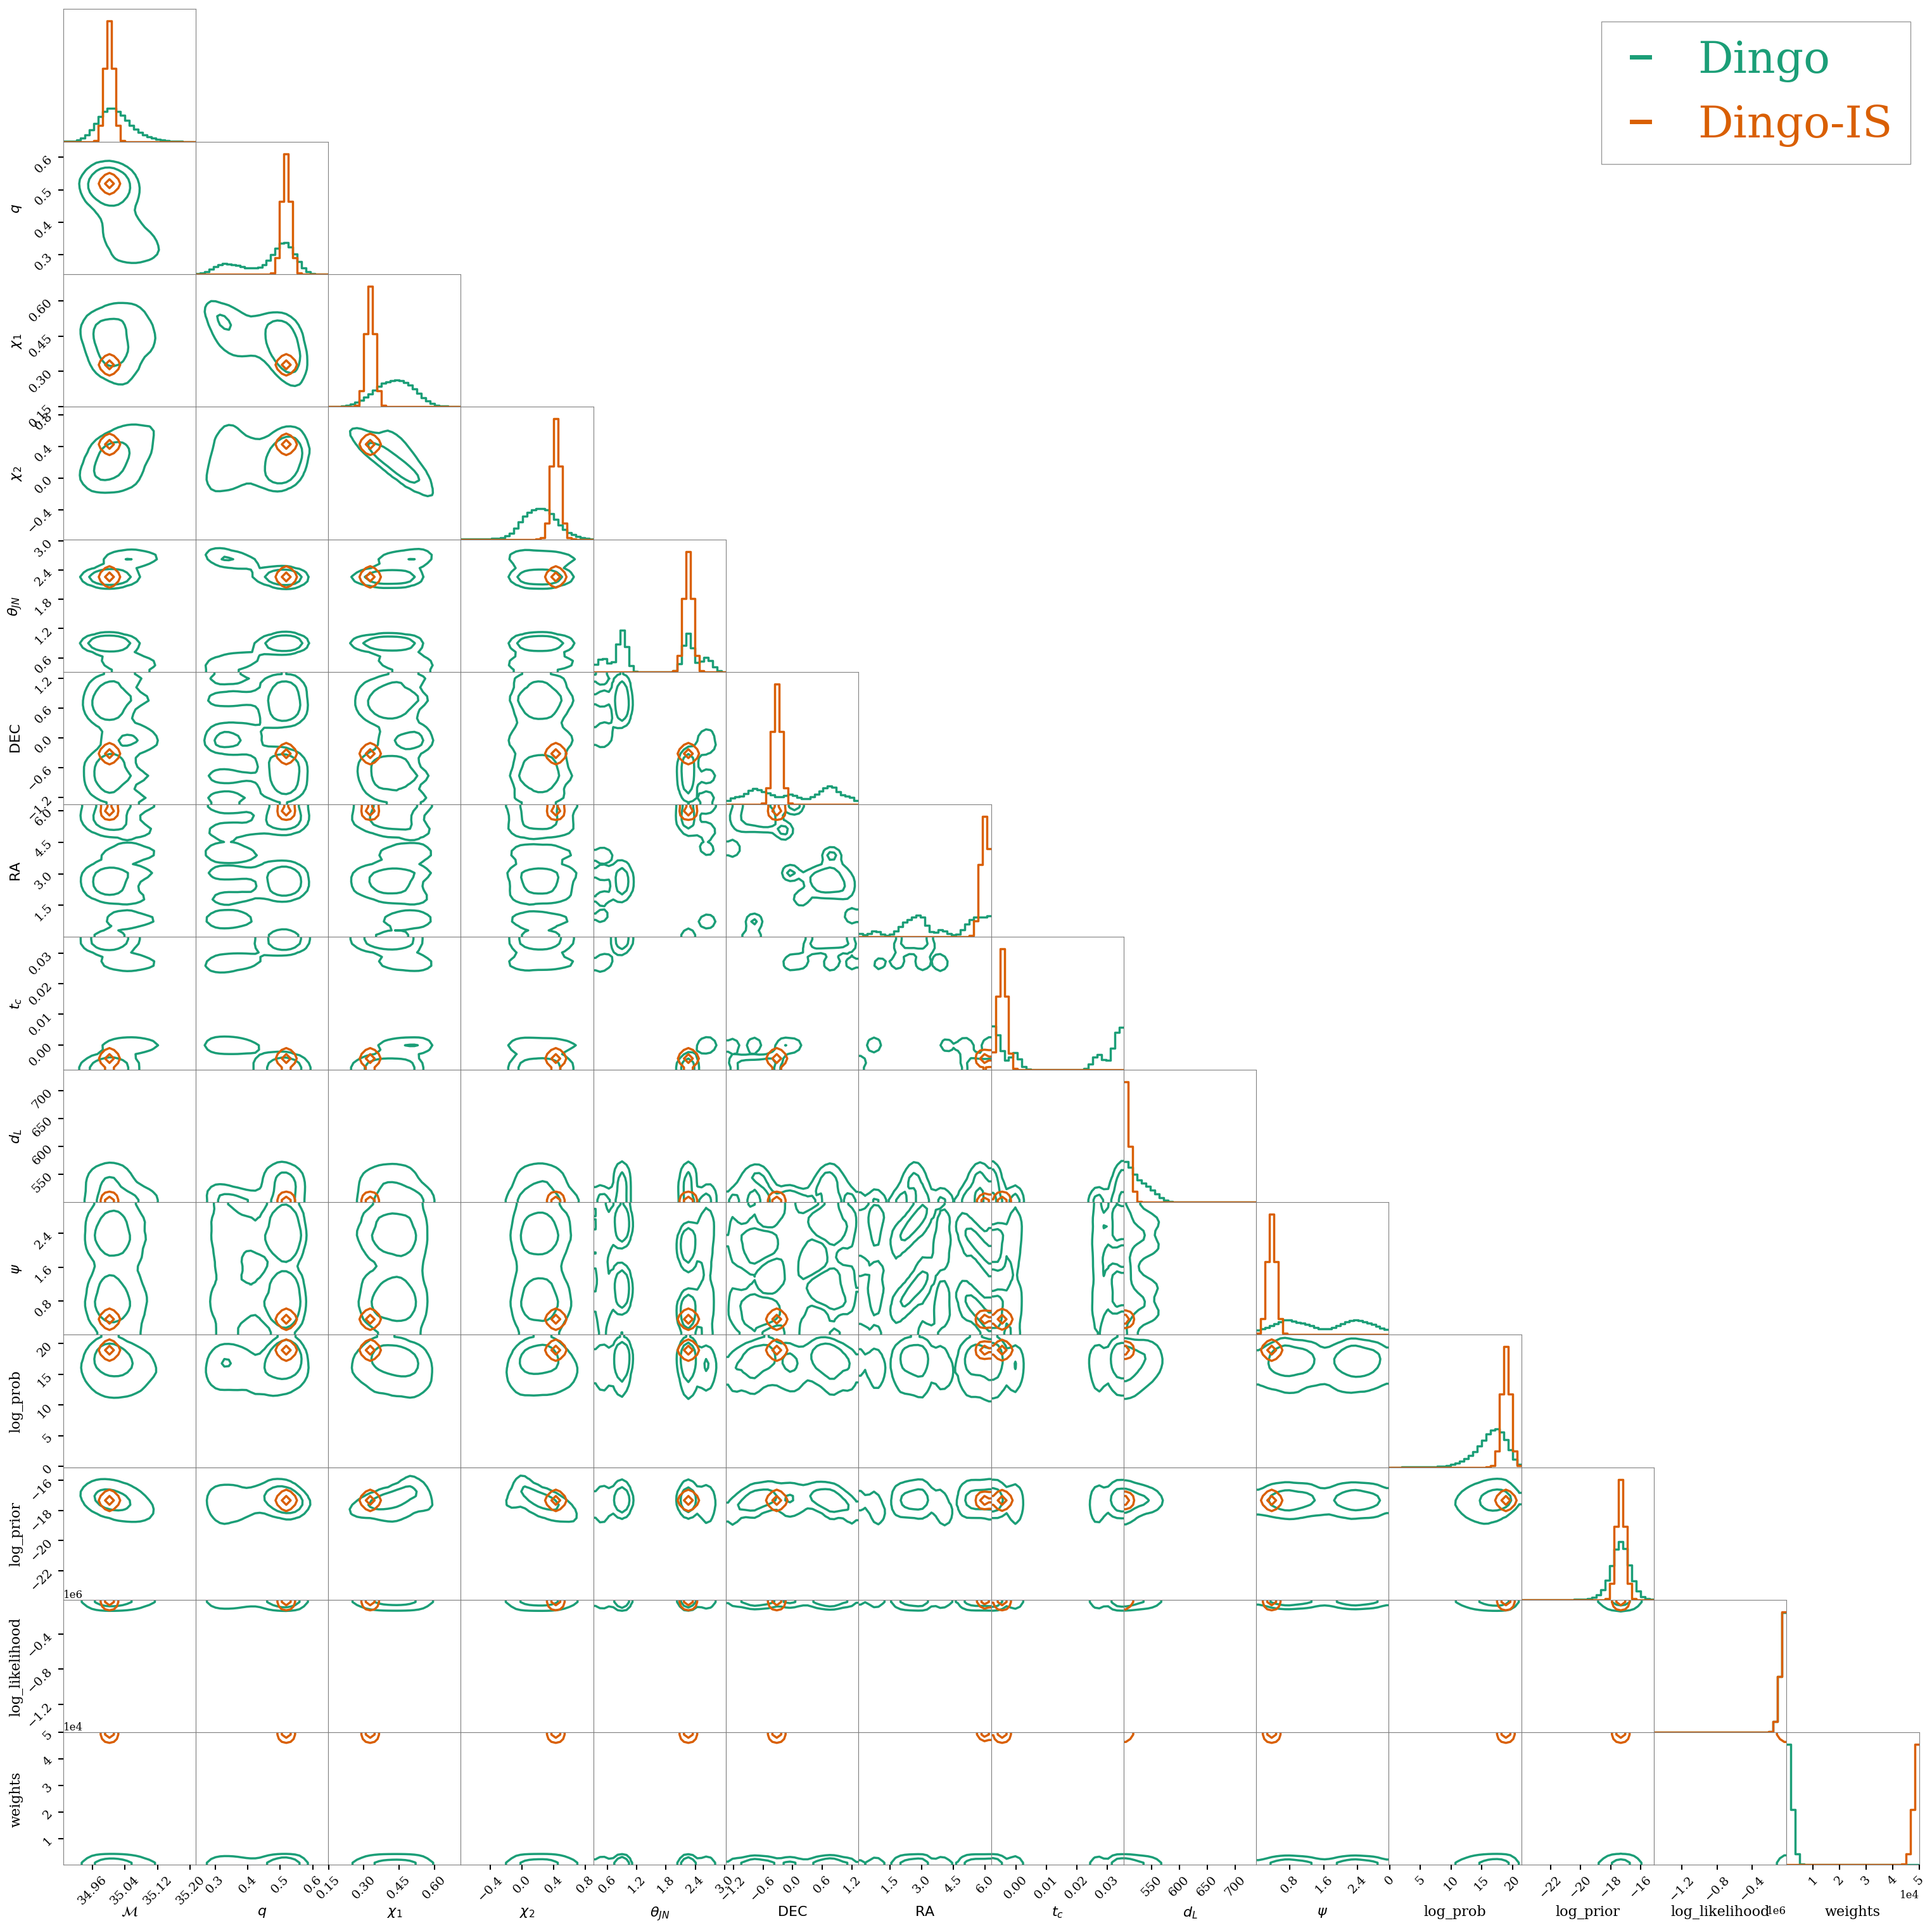

In [5]:
from dingo.gw.inference.gw_samplers import GWSampler

# 1. Re-run the sampler to get a fresh result
sampler2 = GWSampler(model=main_pm)
sampler2.context = strain_data
sampler2.run_sampler(num_samples=50_000, batch_size=10_000)
result2 = sampler2.to_result()

# 2. Fix the prior before importance sampling touches it
for key in ["mass_1", "mass_2"]:
    if key in result2.prior:
        del result2.prior[key]

print("Prior keys after fix:", sorted(result2.prior.keys()))
# Should now match sample cols exactly (minus log_prob)

# 3. Run importance sampling on the clean result
result2.importance_sample(
    num_processes=32,
    phase_marginalization_kwargs={},
)

print(f"Sample efficiency: {result2.sample_efficiency:.3f}")
print(f"log Bayes factor:  {result2.log_bayes_factor:.2f}")
result2.plot_corner()

150 Epoch model:


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Putting posterior model to device cuda.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Loading dataset from training_data/asds_ET_T2.hdf5.
Running sampler to generate 50000 samples.
Done. This took 4.9 s.



WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.


WARNING!

This object was created using Dingo version 0.1.dev1174+g45666b754 < 0.9.0, which broke backwards compatibility.
For models trained prior to this change, new inference results will be unreliable.
Previously-generated result files should be used with caution.
Reasons for backward compatibility breaking:

v0.9.0: Change to window factor usage, see https://git.ligo.org/pe/pe-group-coordination/-/issues/1#note_1469386.



Setting spin_conversion_phase = 0.0. Using this value for the phase parameter for conversion to cartesian spins.
Using phase marginalization with (2,2) mode approximation.
Calculating 49109 likelihoods.


/home/tpausch/.conda/envs/ET-DINGO/lib/python3.10/site-packages/bilby/core/prior/dict.py:603: RuntimeWarning: divide by zero encountered in log
  keep = np.log(np.array(self.evaluate_constraints(subsample), dtype=bool))


Done. This took 58.27 seconds.
Sample efficiency: 0.000
log Bayes factor: -2.22


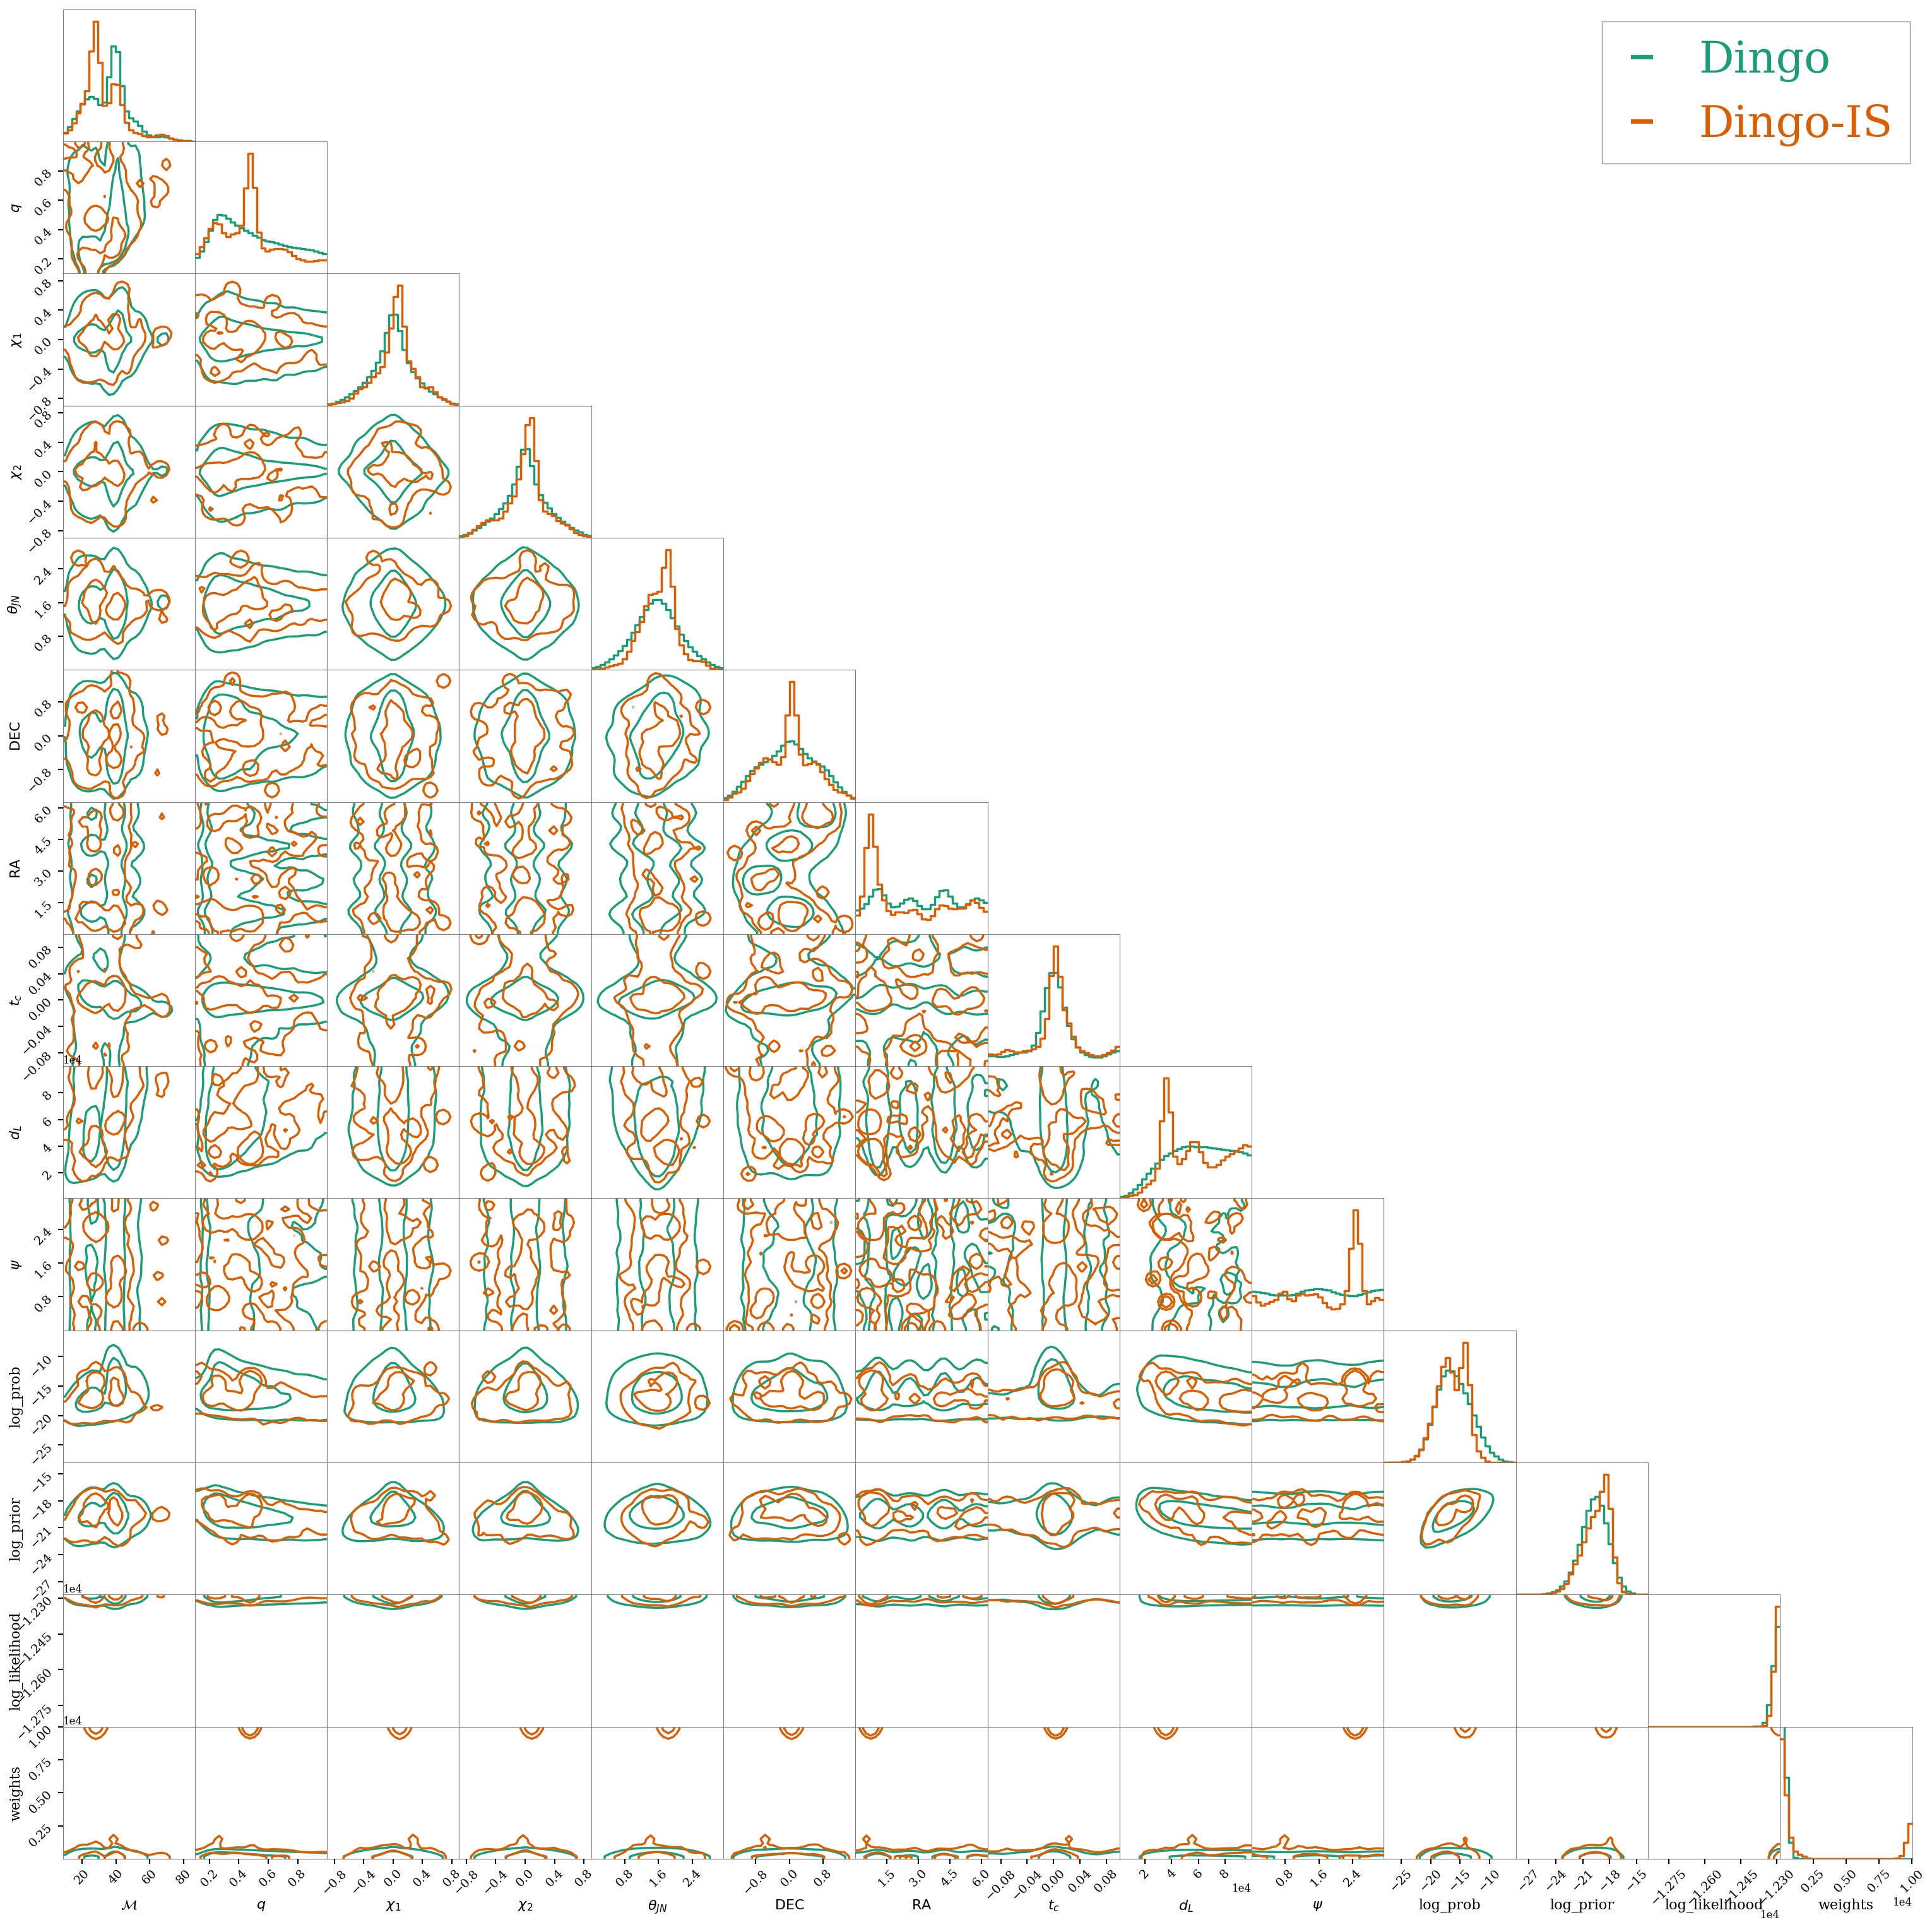

In [7]:
from dingo.core.posterior_models.build_model import build_model_from_kwargs

#main_pm = build_model_from_kwargs(
#    filename="/scratch/tpausch/models/ET_T2/model_latest.pt",
#    device="cuda",
#    load_training_info=False,
#)

main_pm = build_model_from_kwargs(
    filename="/scratch/tpausch/models/ET_T2/model_latest.pt",
    device="cuda",
    load_training_info=False,
)


import dingo.gw.injection as injection
from dingo.gw.noise.asd_dataset import ASDDataset

injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)


injection_generator = injection.Injection.from_posterior_model_metadata(main_pm.metadata)
asd_fname = main_pm.metadata["train_settings"]["training"]["stage_0"]["asd_dataset_path"]
asd_dataset = ASDDataset(file_name=asd_fname)
injection_generator.asd = {k:v[0] for k,v in asd_dataset.asds.items()}

intrinsic_parameters = {
    "chirp_mass": 80.,
    "mass_ratio": 0.8,
    "a_1": .3,
    "a_2": .5,
    "tilt_1": 0.,
    "tilt_2": 0.,
    "phi_jl": 0.,
    "phi_12": 0.
}

extrinsic_parameters = {
    'phase': 0.,
    'theta_jn': 2.3,
    'geocent_time': 0.,
    'luminosity_distance': 5000000000.,
    'ra': 0.,
    'dec': 0.,
    'psi': 0.,
}

theta = {**intrinsic_parameters, **extrinsic_parameters}
strain_data = injection_generator.injection(theta)
# Returns dict with keys: 'waveform', 'parameters', 'extrinsic_parameters', 'asd'



from dingo.gw.inference.gw_samplers import  GWSampler
sampler =GWSampler(model=main_pm)
sampler.context = strain_data
sampler.run_sampler(num_samples=50_000, batch_size=10_000)
result = sampler.to_result()





from dingo.gw.inference.gw_samplers import GWSampler

result = sampler.to_result()



result.importance_sample(
    num_processes=32,
    phase_marginalization_kwargs={},
)

# These are now available after importance sampling:
print(f"Sample efficiency: {result.sample_efficiency:.3f}")  # ideally > ~10%
print(f"log Bayes factor: {result.log_bayes_factor:.2f}")

result.plot_corner()